In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [43]:
z0 = 9.5
x0 = 0.5
vz0 = 0
vx0 = 1
g = -10
rho_f = 1000
rho_p = 2000
vz =  g * (1-rho_f/rho_p)
v = np.sqrt(vx0**2+vz**2)
print(vx0/v)
print(vz/v)

0.19611613513818404
-0.9805806756909202


In [33]:
z0 = 9.5
vz0 = 0
g = -10
rho_f = 1000
rho_p = 2000
dt = [0.2, 0.1, 0.05, 0.025, 0.0125]
n_steps = [11, 20, 40, 79, 157]
t_max = [1.85, 1.9, 1.92436, 1.93686, 1.94311]
h = []
t = []
z_a = []
z_n = []
for i in range(5):
    h.append(1/dt[i])
    t.append(np.linspace(0, t_max[i], n_steps[i]))
    z_a.append(z0 + vz0 * t[i] + 0.5 * g * (1-rho_f/rho_p) * t[i]**2)
    file_name = "../output_files/free_" + str(dt[i]) + ".csv"
    csv_data = np.loadtxt(file_name, delimiter=',')
    z_n.append(csv_data[:,3])

In [34]:
RMSE = []
sum_e_2 = []
for i in range(5):
    N = t[i].shape[0]
    z_anal = z_a[i]
    z_num = z_n[i]
    e = (z_anal - z_num)**2 
    sum_e_2.append(np.sum(e))
    #RMSE.append(np.sqrt(1/N * sum_e_2[i]))
    RMSE.append(np.sqrt(sum_e_2[i]*dt[i]))
print(RMSE)

[np.float64(1.5989924105217792), np.float64(0.3929058411375436), np.float64(0.3444535942023746), np.float64(0.1754422561828809), np.float64(0.08997651310121042)]


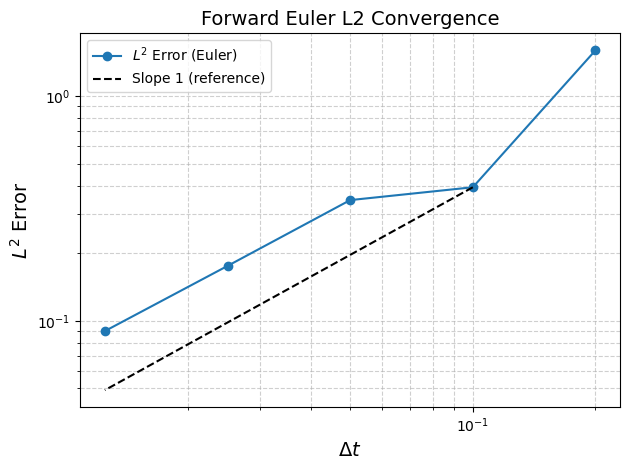

In [35]:
plt.loglog(dt, RMSE, 'o-', label=r'$L^2$ Error (Euler)')
plt.xlabel(r'$\Delta t$', fontsize=14)
plt.ylabel(r'$L^2$ Error', fontsize=14)
plt.title('Forward Euler L2 Convergence', fontsize=14)
plt.grid(True, which='both', linestyle='--', alpha=0.6)

# Reference slope = 1 line
ref_line_x = np.array([dt[1], dt[-1]])
ref_line_y = RMSE[1] * (ref_line_x / dt[1])**1  # slope 1
plt.loglog(ref_line_x, ref_line_y, 'k--', label='Slope 1 (reference)')

plt.legend()
plt.tight_layout()
plt.show()

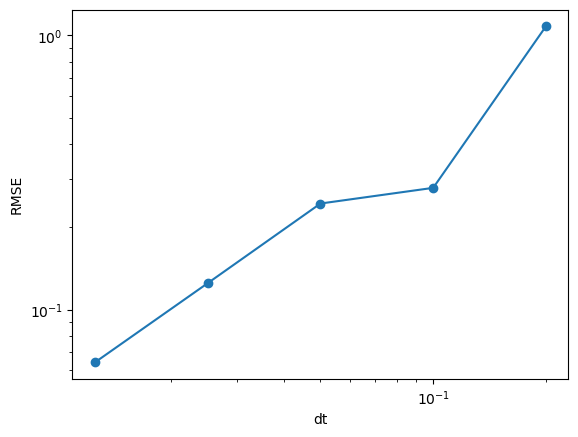

In [20]:
plt.plot(dt, RMSE, marker='o')
plt.xlabel("dt")
plt.ylabel("RMSE")
plt.yscale('log')
plt.xscale('log')

In [37]:
# Fit a linear polynomial (degree 1) to the data
slope, intercept = np.polyfit(np.log(dt), np.log(RMSE), 1)

# Print the slope
print(f'Slope: {slope}')

Slope: 0.9466128990264896


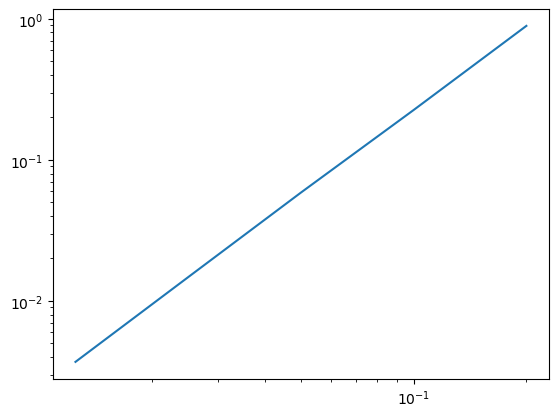

In [23]:
error = []
for i in range(5):
  e = (z_a[i][-1] - z_n[i][-1])**2
  error.append(e)

plt.plot(dt, error)
plt.xscale('log')
plt.yscale('log')

In [26]:
# Fit a linear polynomial (degree 1) to the data
slope, intercept = np.polyfit(np.log10(dt), np.log10(error), 1)

# Print the slope
print(f'Slope: {slope}')

Slope: 1.9759734602222148


In [ ]:
t = np.linspace(0, 2, 11)
z = z0 + vz0 * t + 0.5 * g * (1-rho_f/rho_p) * t**2
print(t)
print(z)

[0.  0.2 0.4 0.6 0.8 1.  1.2 1.4 1.6 1.8 2. ]
[ 9.5  9.4  9.1  8.6  7.9  7.   5.9  4.6  3.1  1.4 -0.5]


In [11]:
def track_particle(dt, rho_f, rho_p, x0, vx0, g, t_end=2):
    # Particle properties
    V = 2.0  # assume unit volume
    m = rho_p * V

    # Buoyancy force
    Fb = (rho_f - rho_p) * V * g

    # Initial conditions
    x = x0
    vx = vx0

    # Time integration
    t_vals = [0.0]
    x_vals = [x]
    vx_vals = [vx]

    t = 0.0
    while t < t_end:
        # Acceleration due to net force
        a = Fb / m

        # Forward Euler update
        vx += a * dt
        x += vx * dt

        # Store values
        t += dt
        t_vals.append(t)
        x_vals.append(x)
        vx_vals.append(vx)

    return np.array(t_vals), np.array(x_vals), np.array(vx_vals)

In [13]:
dt = 0.2        # time step
rho_f = 1000.0   # fluid density
rho_p = 2000    # particle density
x0 = 9.5       # initial position
vx0 = 0.0        # initial velocity
g = 10        # gravity

# Run simulation
t, x, vx = track_particle(dt, rho_f, rho_p, x0, vx0, g)


print(t)
print(x)
  # # Plot position over time
  # plt.figure(figsize=(8, 4))
  # plt.plot(t, x, label='Particle position')
  # plt.xlabel('Time [s]')
  # plt.ylabel('Position [m]')
  # plt.title('1D Particle Tracking under Buoyancy')
  # plt.grid(True)
  # plt.legend()
  # plt.tight_layout()
  # plt.show()

[0.  0.2 0.4 0.6 0.8 1.  1.2 1.4 1.6 1.8 2.  2.2]
[ 9.5  9.3  8.9  8.3  7.5  6.5  5.3  3.9  2.3  0.5 -1.5 -3.7]


In [16]:
Re_r = 0.5
g = -10
rho_f = 1000
rho_p = 2000
mu = 1e-3
d = np.cbrt(Re_r * 18 * mu**2 / (g * rho_f * (rho_p - rho_f)))
print(d)

-9.654893846056297e-05


In [23]:
d = 1e-1
v = -5e-06
f =  ((1-rho_f/rho_p) * g - 18*mu*v / (rho_p * d**2))
print(f)

-4.9999999955
